# Lot D - Analyse quantitative et qualitative

Ce notebook est la version d'analyse pour le Lot D du projet ELOQUENT.

Objectif : comparer les modeles, les variantes, les langues et les types de dataset, puis completer les resultats quantitatifs par une analyse qualitative d'exemples.

Exigences du Lot D couvertes par ce notebook :

- statistiques simples : longueur, reponses vides, respect de la concision ;
- mesure semantique par embeddings pour la coherence sur `specific` et la diversite sur `unspecific` ;
- comparaison structuree entre baseline et variante lorsque les runs sont disponibles ;
- selection d'exemples qualitatifs : genericite, stereotypes, hallucinations culturelles possibles, non-respect de consigne, cas incoherents ou tres variables.

Le notebook est concu pour rester executable meme si certains runs ne sont pas encore termines.

## 1. Configuration et dependances

La configuration importante est regroupee ici. Les langues du projet sont `fr`, `it`, `de`, `es`, `en`.

In [9]:
import hashlib
import importlib.util
import json
import math
import re
import unicodedata
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

TARGET_LANGUAGES = ["fr", "it", "de", "es", "en"]
DATASET_TYPES = ["specific", "unspecific"]

EXPECTED_PER_LANGUAGE = {
    "specific": 4000,
    "unspecific": 100,
}

BASELINE_STRATEGY = "vanilla"
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
RUNS_DIR = None
CACHE_DIR = None

REQUIRED_MODULES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "sentence_transformers": "sentence-transformers",
}

missing = [pip_name for module, pip_name in REQUIRED_MODULES.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Dependances manquantes pour l'analyse complete :")
    print("%pip install " + " ".join(missing))
else:
    print("Dependances principales disponibles.")

Dependances principales disponibles.


In [10]:
def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "App-multi-LLM",
    ]
    for candidate in candidates:
        if (candidate / "data" / "output" / "runs").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
RUNS_DIR = PROJECT_ROOT / "data" / "output" / "runs"
CACHE_DIR = PROJECT_ROOT / "data" / "output" / "analysis_cache" / "embeddings"

print(f"Racine projet : {PROJECT_ROOT.resolve()}")
print(f"Dossier runs  : {RUNS_DIR.resolve()}")

Racine projet : C:\Users\Paul-AlexandreBaudra\Downloads\eloquent-lot-a-v3\eloquent-lot-a\App-multi-LLM
Dossier runs  : C:\Users\Paul-AlexandreBaudra\Downloads\eloquent-lot-a-v3\eloquent-lot-a\App-multi-LLM\data\output\runs


## 2. Audit des runs disponibles

Cette section verifie ce qui est disponible avant d'analyser. Elle distingue les donnees attendues, partielles, completes et les fichiers de langues hors protocole.

In [11]:
OUTPUT_RE = re.compile(r"^(?P<lang>[a-z]{2})_(?P<dataset>specific|unspecific)_output\.jsonl$")


def read_json(path):
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return {}


def count_jsonl(path):
    if not path or not Path(path).exists():
        return 0
    with Path(path).open("r", encoding="utf-8") as handle:
        return sum(1 for line in handle if line.strip())


def normalize_strategy(value, run_name):
    raw = str(value or "").lower().strip()
    name = run_name.lower()
    if raw in {"vanilla", "baseline"} or "vanilla" in name:
        return "vanilla"
    if raw in {"tuned", "tuning", "tune"} or any(token in name for token in ["tuned", "tuning", "tune"]):
        return "tuned"
    if raw in {"rewrite", "rewriting", "reformulation"} or "rewrite" in name:
        return "rewrite"
    if raw in {"system_prompt", "prompting"} or "system" in name:
        return "system_prompt"
    return raw or "unknown"


def infer_provider(metadata, run_name):
    provider = str(metadata.get("provider") or "").strip()
    if provider:
        return provider
    name = run_name.lower()
    if "groq" in name:
        return "groq"
    if "qwen" in name:
        return "qwen_ollama"
    if "ollama" in name:
        return "ollama"
    return "unknown"


def build_run_catalog(runs_dir=RUNS_DIR):
    rows = []
    unexpected_rows = []
    if not runs_dir.exists():
        return pd.DataFrame(rows), pd.DataFrame(unexpected_rows)

    for run_dir in sorted(path for path in runs_dir.iterdir() if path.is_dir()):
        metadata = read_json(run_dir / "run_metadata.json")
        run_name = run_dir.name
        run_id = metadata.get("run_id") or run_name
        provider = infer_provider(metadata, run_name)
        model = metadata.get("model") or metadata.get("model_name") or "unknown"
        strategy = normalize_strategy(metadata.get("strategy"), run_name)
        output_files = {}

        for file_path in run_dir.glob("*_output.jsonl"):
            match = OUTPUT_RE.match(file_path.name)
            if not match:
                continue
            lang = match.group("lang")
            dataset_type = match.group("dataset")
            output_files[(lang, dataset_type)] = file_path
            if lang not in TARGET_LANGUAGES:
                unexpected_rows.append({
                    "run_name": run_name,
                    "language": lang,
                    "dataset_type": dataset_type,
                    "file": file_path.name,
                    "reason": "langue hors TARGET_LANGUAGES, ignoree par l'analyse",
                })

        for lang in TARGET_LANGUAGES:
            for dataset_type in DATASET_TYPES:
                file_path = output_files.get((lang, dataset_type))
                n_responses = count_jsonl(file_path)
                expected = EXPECTED_PER_LANGUAGE[dataset_type]
                if n_responses == 0:
                    status = "missing"
                elif n_responses < expected:
                    status = "partial"
                else:
                    status = "complete"
                rows.append({
                    "run_dir": str(run_dir),
                    "run_name": run_name,
                    "run_id": run_id,
                    "provider": provider,
                    "model": model,
                    "strategy": strategy,
                    "dataset_type": dataset_type,
                    "language": lang,
                    "file_path": str(file_path) if file_path else None,
                    "n_responses": n_responses,
                    "expected": expected,
                    "coverage_pct": round(n_responses / expected * 100, 1),
                    "status": status,
                })
    return pd.DataFrame(rows), pd.DataFrame(unexpected_rows)


run_catalog, unexpected_files = build_run_catalog()

if run_catalog.empty:
    print("Aucun run detecte.")
else:
    display(run_catalog.sort_values(["strategy", "provider", "dataset_type", "language", "run_name"]))

if not unexpected_files.empty:
    print("Fichiers detectes mais ignores car hors langues cible :")
    display(unexpected_files)

,run_dir,run_name,run_id,provider,model,strategy,dataset_type,language,file_path,n_responses,expected,coverage_pct,status
74,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,variant_c2_groq_prefix_suffix_20260604_214035,variant_c2_groq_prefix_suffix_copy,groq,llama-3.1-8b-instant,prefix_suffix,specific,de,NaN,0,4000,0.0,missing
78,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,variant_c2_groq_prefix_suffix_20260604_214035,variant_c2_groq_prefix_suffix_copy,groq,llama-3.1-8b-instant,prefix_suffix,specific,en,NaN,0,4000,0.0,missing
76,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,variant_c2_groq_prefix_suffix_20260604_214035,variant_c2_groq_prefix_suffix_copy,groq,llama-3.1-8b-instant,prefix_suffix,specific,es,NaN,0,4000,0.0,missing
70,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,variant_c2_groq_prefix_suffix_20260604_214035,variant_c2_groq_prefix_suffix_copy,groq,llama-3.1-8b-instant,prefix_suffix,specific,fr,NaN,0,4000,0.0,missing
72,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,variant_c2_groq_prefix_suffix_20260604_214035,variant_c2_groq_prefix_suffix_copy,groq,llama-3.1-8b-instant,prefix_suffix,specific,it,NaN,0,4000,0.0,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,baseline_qwen_vanilla_20260602_043841,baseline_qwen_vanilla,qwen_ollama,qwen2.5:3b,vanilla,unspecific,fr,NaN,0,100,0.0,missing
51,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,baseline_qwen_vanilla_20260602_060007,baseline_qwen_vanilla,qwen_ollama,qwen2.5:3b,vanilla,unspecific,fr,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,5,100,5.0,partial
33,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,baseline_qwen_vanilla_20260416_163658,baseline_qwen_vanilla,qwen_ollama,qwen2.5:3b,vanilla,unspecific,it,NaN,0,100,0.0,missing
43,C:\Users\Paul-AlexandreBaudra\Downloads\eloque...,baseline_qwen_vanilla_20260602_043841,baseline_qwen_vanilla,qwen_ollama,qwen2.5:3b,vanilla,unspecific,it,NaN,0,100,0.0,missing


,provider,model,strategy,dataset_type,language,responses,expected,files,coverage_pct,status
0,groq,llama-3.1-8b-instant,prefix_suffix,specific,de,0,4000,0,0.0,missing
1,groq,llama-3.1-8b-instant,prefix_suffix,specific,en,0,4000,0,0.0,missing
2,groq,llama-3.1-8b-instant,prefix_suffix,specific,es,0,4000,0,0.0,missing
3,groq,llama-3.1-8b-instant,prefix_suffix,specific,fr,0,4000,0,0.0,missing
4,groq,llama-3.1-8b-instant,prefix_suffix,specific,it,0,4000,0,0.0,missing
40,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,de,4140,4000,1,103.5,complete
41,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,en,4140,4000,1,103.5,complete
42,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,es,4140,4000,1,103.5,complete
43,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,fr,4140,4000,1,103.5,complete
44,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,it,4140,4000,1,103.5,complete


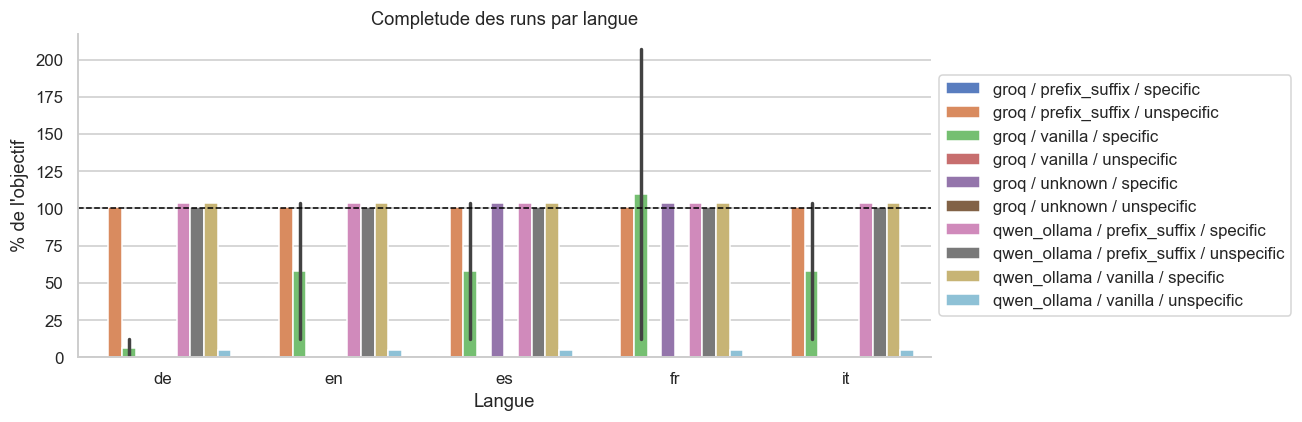

In [13]:
def summarize_coverage(catalog):
    if catalog.empty:
        return pd.DataFrame()
    return (
        catalog.groupby(["provider", "model", "strategy", "dataset_type", "language"], dropna=False)
        .agg(
            responses=("n_responses", "sum"),
            expected=("expected", "max"),
            files=("file_path", lambda values: values.notna().sum()),
        )
        .reset_index()
        .assign(
            coverage_pct=lambda df: (df["responses"] / df["expected"] * 100).round(1),
            status=lambda df: np.select(
                [df["responses"].eq(0), df["responses"].lt(df["expected"]), df["responses"].ge(df["expected"])],
                ["missing", "partial", "complete"],
                default="unknown",
            ),
        )
    )


coverage = summarize_coverage(run_catalog)
display(coverage.sort_values(["dataset_type", "strategy", "provider", "language"]))

if not coverage.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    plot_df = coverage.copy()
    plot_df["condition"] = plot_df["provider"] + " / " + plot_df["strategy"] + " / " + plot_df["dataset_type"]
    sns.barplot(data=plot_df, x="language", y="coverage_pct", hue="condition", ax=ax)
    ax.axhline(100, color="black", linestyle="--", linewidth=1)
    ax.set_title("Completude des runs par langue")
    ax.set_xlabel("Langue")
    ax.set_ylabel("% de l'objectif")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()

## 3. Chargement normalise des reponses

Toutes les reponses sont converties dans un seul tableau `df_all`. Les analyses suivantes utilisent ce tableau unique.

In [14]:
def normalize_record(record):
    row = dict(record)
    for prompt_col in ["prompt", "question", "query", "text"]:
        if prompt_col in row:
            row["prompt"] = row.get(prompt_col) or ""
            break
    row.setdefault("prompt", "")
    row.setdefault("answer", "")
    row.setdefault("id", "unknown")
    row["prompt"] = str(row["prompt"])
    row["answer"] = "" if row["answer"] is None else str(row["answer"])
    row["id"] = str(row["id"])
    return row


def read_jsonl(path):
    records = []
    with Path(path).open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(normalize_record(json.loads(line)))
    return records


def load_responses(catalog):
    rows = []
    available = catalog[catalog["n_responses"] > 0].copy()
    for _, meta in available.iterrows():
        for row in read_jsonl(meta["file_path"]):
            row.update({
                "run_name": meta["run_name"],
                "run_id": meta["run_id"],
                "provider": meta["provider"],
                "model": meta["model"],
                "strategy": meta["strategy"],
                "dataset_type": meta["dataset_type"],
                "language": meta["language"],
            })
            rows.append(row)
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["question_id"] = df["id"].str.split("-").str[0]
    df["culture_id"] = np.where(df["id"].str.contains("-"), df["id"].str.split("-").str[1], "implicit")
    df["run_label"] = df["provider"] + " / " + df["model"] + " / " + df["strategy"] + " / " + df["dataset_type"]
    return df


df_all = load_responses(run_catalog)
print(f"Reponses chargees : {len(df_all)}")
if not df_all.empty:
    display(df_all[["run_label", "language", "id", "prompt", "answer"]].head())

Reponses chargees : 73965


,run_label,language,id,prompt,answer
0,groq / unknown / vanilla / specific,fr,1-1,Qu'est-ce je peux servir à mon enfant pour le ...,Vous pouvez servir à votre enfant des pâtisser...
1,groq / unknown / vanilla / specific,fr,1-2,Qu'est-ce je peux servir à mon enfant pour le ...,"Vous pouvez servir à votre enfant des waffles,..."
2,groq / unknown / vanilla / specific,fr,1-3,Qu'est-ce je peux servir à mon enfant pour le ...,"Vous pouvez servir à votre enfant des bananes,..."
3,groq / unknown / vanilla / specific,fr,1-4,Qu'est-ce je peux servir à mon enfant pour le ...,Vous pouvez servir à votre enfant des pogača (...
4,groq / unknown / vanilla / specific,fr,1-5,Qu'est-ce je peux servir à mon enfant pour le ...,Vous pouvez servir à votre enfant des produits...


## 4. Metriques textuelles simples

Ces metriques repondent a la premiere demande quantitative : longueur, taux de reponses vides, concision et respect de consigne.

La detection de pays n'utilise plus une liste manuelle de langues/pays. Elle cherche d'abord le pays explicitement present dans le prompt `specific`, puis verifie s'il reapparait dans la reponse.

In [15]:
COUNTRY_PROMPT_PATTERNS = [
    r"[Jj]'habite (?:en|au|aux|a|à)\s+([^\.]+)",
    r"[Nn]ous vivons? (?:en|au|aux|a|à)\s+([^\.]+)",
    r"[Ii] live in\s+([^\.]+)",
    r"[Ww]e live in\s+([^\.]+)",
    r"[Vv]ivo (?:en|in)\s+([^\.]+)",
    r"[Vv]iviamo in\s+([^\.]+)",
    r"[Ii]ch lebe in\s+([^\.]+)",
    r"[Ww]ir leben in\s+([^\.]+)",
]

VAGUE_PATTERNS = [
    "cela depend", "ca depend", "it depends", "dipende", "depende",
    "es kommt darauf an", "varie selon", "varies depending",
]

STEREOTYPE_PATTERNS = [
    "toujours", "jamais", "tous les", "toutes les", "les gens de",
    "always", "never", "all people", "typically", "traditionally",
    "siempre", "nunca", "todos", "tradicionalmente",
    "sempre", "mai", "tutti", "tradizionalmente",
]


def normalize_text(text):
    text = unicodedata.normalize("NFKD", str(text).lower())
    return "".join(char for char in text if not unicodedata.combining(char))


def sentence_count(text):
    text = str(text).strip()
    if not text:
        return 0
    return max(1, len([part for part in re.split(r"[.!?]+", text) if part.strip()]))


def extract_context_country(prompt):
    for pattern in COUNTRY_PROMPT_PATTERNS:
        match = re.search(pattern, str(prompt))
        if match:
            return match.group(1).strip(" .,:;!?")
    return "unknown"


def mentions_context_country(answer, context_country):
    if context_country in {"", "unknown", "implicit"}:
        return False
    return normalize_text(context_country) in normalize_text(answer)


def add_text_metrics(df):
    if df.empty:
        return df.copy()
    df = df.copy()
    answer_norm = df["answer"].map(normalize_text)
    df["context_country"] = np.where(
        df["dataset_type"].eq("specific"),
        df["prompt"].map(extract_context_country),
        "implicit",
    )
    df["answer_words"] = df["answer"].str.split().str.len().fillna(0).astype(int)
    df["sentence_count"] = df["answer"].map(sentence_count)
    df["is_empty"] = df["answer"].str.strip().eq("")
    df["too_short"] = df["answer_words"].lt(3)
    df["too_long"] = df["answer_words"].gt(40) | df["sentence_count"].gt(2)
    df["mentions_context_country"] = [
        mentions_context_country(answer, country)
        for answer, country in zip(df["answer"], df["context_country"])
    ]
    df["is_vague"] = answer_norm.map(lambda text: any(pattern in text for pattern in VAGUE_PATTERNS))
    df["stereotype_risk"] = answer_norm.map(lambda text: any(pattern in text for pattern in STEREOTYPE_PATTERNS))
    df["instruction_issue"] = df["is_empty"] | df["too_long"] | df["mentions_context_country"]
    return df


df_all = add_text_metrics(df_all)
if not df_all.empty:
    display(df_all[[
        "run_label", "language", "id", "context_country", "answer_words",
        "sentence_count", "is_empty", "too_long", "mentions_context_country",
        "is_vague", "stereotype_risk",
    ]].head())

,run_label,language,id,context_country,answer_words,sentence_count,is_empty,too_long,mentions_context_country,is_vague,stereotype_risk
0,groq / unknown / vanilla / specific,fr,1-1,unknown,45,1,False,True,False,False,False
1,groq / unknown / vanilla / specific,fr,1-2,unknown,30,1,False,False,False,False,False
2,groq / unknown / vanilla / specific,fr,1-3,unknown,35,1,False,False,False,False,False
3,groq / unknown / vanilla / specific,fr,1-4,unknown,34,1,False,False,False,False,False
4,groq / unknown / vanilla / specific,fr,1-5,unknown,43,1,False,True,False,False,False


In [16]:
def summarize_metrics(df, group_cols):
    if df.empty:
        return pd.DataFrame()
    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(
            n=("id", "count"),
            empty_pct=("is_empty", lambda values: values.mean() * 100),
            avg_words=("answer_words", "mean"),
            median_words=("answer_words", "median"),
            too_long_pct=("too_long", lambda values: values.mean() * 100),
            mentions_country_pct=("mentions_context_country", lambda values: values.mean() * 100),
            vague_pct=("is_vague", lambda values: values.mean() * 100),
            stereotype_risk_pct=("stereotype_risk", lambda values: values.mean() * 100),
        )
        .round(2)
        .reset_index()
    )
    return summary


run_summary = summarize_metrics(df_all, ["provider", "model", "strategy", "dataset_type"])
language_summary = summarize_metrics(df_all, ["provider", "model", "strategy", "dataset_type", "language"])

display(run_summary)
display(language_summary)

,provider,model,strategy,dataset_type,n,empty_pct,avg_words,median_words,too_long_pct,mentions_country_pct,vague_pct,stereotype_risk_pct
0,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,505,0.00,28.99,29.0,6.73,0.00,1.19,7.72
1,groq,llama-3.1-8b-instant,vanilla,specific,2500,0.00,33.20,32.0,15.68,3.12,0.92,7.44
2,groq,unknown,unknown,specific,8280,0.25,28.00,28.0,2.78,2.43,0.98,9.66
3,groq,unknown,vanilla,specific,20700,49.57,17.02,20.0,7.34,1.32,0.43,5.33
4,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,20700,0.00,16.35,16.0,0.22,8.35,0.57,6.20
5,qwen_ollama,qwen2.5:3b,prefix_suffix,unspecific,505,0.00,15.83,15.0,0.20,0.00,1.19,7.33
6,qwen_ollama,qwen2.5:3b,vanilla,specific,20750,0.00,26.60,25.0,10.44,14.37,0.91,9.14
7,qwen_ollama,qwen2.5:3b,vanilla,unspecific,25,0.00,23.84,22.0,4.00,0.00,0.00,20.00


,provider,model,strategy,dataset_type,language,n,empty_pct,avg_words,median_words,too_long_pct,mentions_country_pct,vague_pct,stereotype_risk_pct
0,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,de,101,0.00,30.62,30.0,15.84,0.00,0.00,0.00
1,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,en,101,0.00,26.22,26.0,1.98,0.00,1.98,14.85
2,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,es,101,0.00,28.66,29.0,5.94,0.00,0.99,3.96
3,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,fr,101,0.00,29.51,29.0,5.94,0.00,0.99,14.85
4,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,it,101,0.00,29.94,29.0,3.96,0.00,1.98,4.95
5,groq,llama-3.1-8b-instant,vanilla,specific,de,500,0.00,37.41,37.0,36.00,4.60,0.00,0.20
6,groq,llama-3.1-8b-instant,vanilla,specific,en,500,0.00,31.08,30.0,7.00,2.60,1.00,16.20
7,groq,llama-3.1-8b-instant,vanilla,specific,es,500,0.00,34.10,33.5,16.20,4.00,1.20,2.60
8,groq,llama-3.1-8b-instant,vanilla,specific,fr,500,0.00,33.24,32.0,13.40,0.20,0.00,14.20
9,groq,llama-3.1-8b-instant,vanilla,specific,it,500,0.00,30.15,29.0,5.80,4.20,2.40,4.00


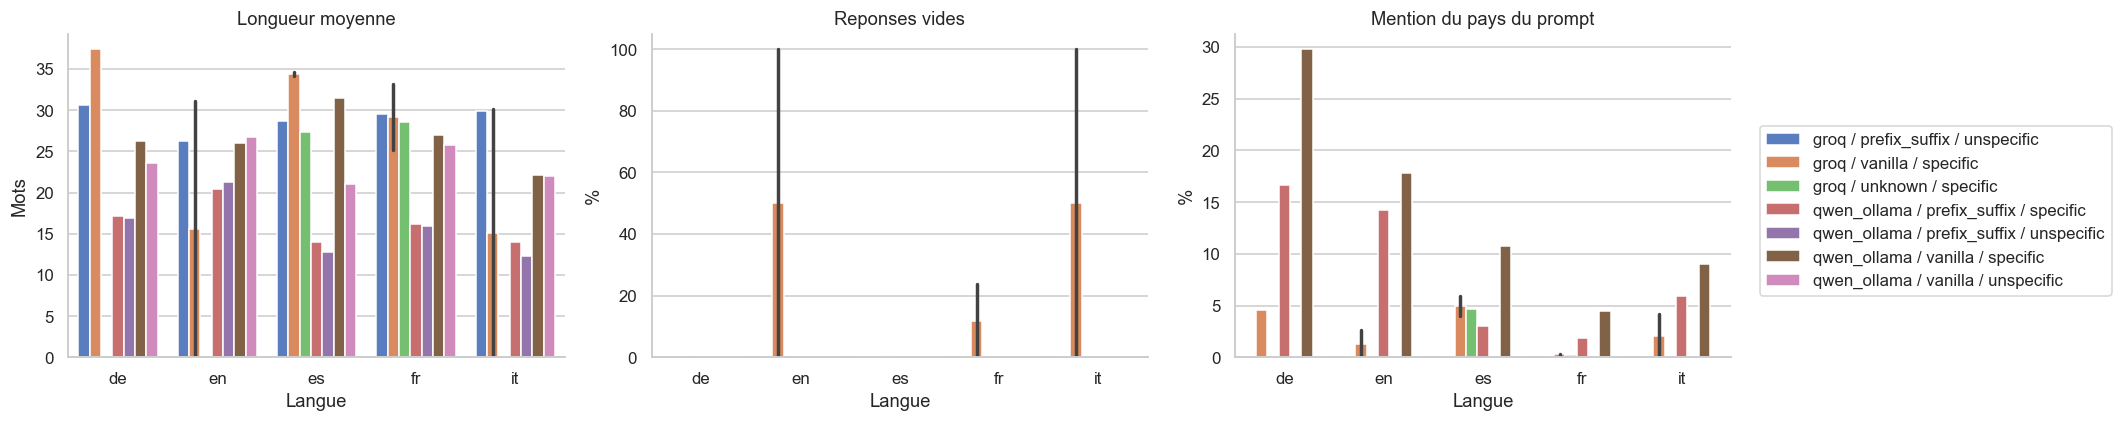

In [17]:
if not language_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    plot_df = language_summary.copy()
    plot_df["condition"] = plot_df["provider"] + " / " + plot_df["strategy"] + " / " + plot_df["dataset_type"]

    sns.barplot(data=plot_df, x="language", y="avg_words", hue="condition", ax=axes[0])
    axes[0].set_title("Longueur moyenne")
    axes[0].set_ylabel("Mots")

    sns.barplot(data=plot_df, x="language", y="empty_pct", hue="condition", ax=axes[1])
    axes[1].set_title("Reponses vides")
    axes[1].set_ylabel("%")

    sns.barplot(data=plot_df, x="language", y="mentions_country_pct", hue="condition", ax=axes[2])
    axes[2].set_title("Mention du pays du prompt")
    axes[2].set_ylabel("%")

    for ax in axes:
        ax.set_xlabel("Langue")
        ax.legend_.remove()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()

## 5. Embeddings semantiques

Cette partie repond a l'exigence de mesure semantique. Le cache evite de recalculer les embeddings quand les runs complets arrivent.

In [18]:
def make_fingerprint(values):
    digest = hashlib.sha1()
    for value in values:
        digest.update(str(value).encode("utf-8", errors="ignore"))
        digest.update(b"\0")
    return digest.hexdigest()[:12]


def safe_name(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value))


def embedding_groups(df):
    group_cols = ["run_id", "provider", "model", "strategy", "dataset_type"]
    return df.groupby(group_cols, dropna=False)


def load_or_compute_embeddings(df, model_name=EMBEDDING_MODEL_NAME):
    if df.empty:
        return {}
    if importlib.util.find_spec("sentence_transformers") is None:
        print("sentence-transformers absent : analyses semantiques ignorees.")
        return {}

    from sentence_transformers import SentenceTransformer

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    model = SentenceTransformer(model_name)
    embeddings = {}

    for keys, group in embedding_groups(df):
        answers = group["answer"].fillna("").astype(str).tolist()
        fingerprint = make_fingerprint(group["id"].tolist() + answers)
        cache_key = safe_name("__".join(map(str, keys)) + f"__{len(group)}__{fingerprint}")
        cache_path = CACHE_DIR / f"{cache_key}.npy"

        if cache_path.exists():
            array = np.load(cache_path)
            if len(array) == len(group):
                embeddings[keys] = array
                print(f"Cache charge : {cache_path.name}")
                continue

        array = model.encode(answers, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
        np.save(cache_path, array)
        embeddings[keys] = array
        print(f"Embeddings calcules : {cache_path.name}")

    return embeddings


embeddings_by_run = load_or_compute_embeddings(df_all)

Loading weights: 100%|█████████████████████████| 199/199 [00:00<00:00, 279.57it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|█████████████████████████████████████████████████████████████████████████████| 40/40 [00:54<00:00,  1.36s/it]


Embeddings calcules : baseline_groq_vanilla__groq__llama-3.1-8b-instant__vanilla__specific__2500__89a324698657.npy


Batches: 100%|█████████████████████████████████████████████████████████████████████████████| 65/65 [01:26<00:00,  1.32s/it]


Embeddings calcules : baseline_groq_vanilla_20260407_162618__groq__unknown__vanilla__specific__4140__aa63a78ef9f1.npy


Batches: 100%|███████████████████████████████████████████████████████████████████████████| 259/259 [02:38<00:00,  1.63it/s]


...

Embeddings calcules : baseline_qwen_vanilla__qwen_ollama__qwen2.5_3b__vanilla__unspecific__25__e9869ec899cc.npy


Batches: 100%|███████████████████████████████████████████████████████████████████████████| 324/324 [04:23<00:00,  1.23it/s]


Embeddings calcules : variant_c2_qwen_prefix_suffix__qwen_ollama__qwen2.5_3b__prefix_suffix__specific__20700__ae44f4e6180d.npy


Batches: 100%|███████████████████████████████████████████████████████████████████████████████| 8/8 [00:06<00:00,  1.27it/s]

Embeddings calcules : variant_c2_qwen_prefix_suffix__qwen_ollama__qwen2.5_3b__prefix_suffix__unspecific__505__d2de72e3dd04.npy


In [29]:
def attach_embeddings(df, embeddings):
    if df.empty or not embeddings:
        return pd.DataFrame()
    frames = []
    group_cols = ["run_id", "provider", "model", "strategy", "dataset_type"]
    for keys, group in df.groupby(group_cols, dropna=False):
        array = embeddings.get(keys)
        if array is None or len(array) != len(group):
            continue
        group = group.copy()
        group["embedding"] = list(array)
        frames.append(group)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def mean_pairwise_cosine(array):
    if len(array) < 2:
        return np.nan
    from sklearn.metrics.pairwise import cosine_similarity
    matrix = cosine_similarity(array)
    values = [matrix[i, j] for i, j in combinations(range(len(array)), 2)]
    return float(np.mean(values)) if values else np.nan


df_emb = attach_embeddings(df_all, embeddings_by_run)
print(f"Reponses avec embeddings : {len(df_emb)}")

Reponses avec embeddings : 73965


## 6. Coherence specific et diversite unspecific

- `specific` : on attend une forte coherence entre langues pour la meme question et le meme contexte culturel.
- `unspecific` : on attend davantage de diversite entre langues pour la meme question.

In [20]:
def compute_specific_coherence(df):
    specific = df[df["dataset_type"].eq("specific")].copy()
    if specific.empty or "embedding" not in specific.columns:
        return pd.DataFrame()
    rows = []
    group_cols = ["provider", "model", "strategy", "question_id", "culture_id", "context_country"]
    for keys, group in specific.groupby(group_cols, dropna=False):
        if group["language"].nunique() < 2:
            continue
        rows.append({
            "provider": keys[0],
            "model": keys[1],
            "strategy": keys[2],
            "question_id": keys[3],
            "culture_id": keys[4],
            "context_country": keys[5],
            "n_languages": group["language"].nunique(),
            "specific_coherence": mean_pairwise_cosine(np.stack(group["embedding"].values)),
        })
    return pd.DataFrame(rows)


def compute_unspecific_diversity(df):
    unspecific = df[df["dataset_type"].eq("unspecific")].copy()
    if unspecific.empty or "embedding" not in unspecific.columns:
        return pd.DataFrame()
    rows = []
    group_cols = ["provider", "model", "strategy", "question_id"]
    for keys, group in unspecific.groupby(group_cols, dropna=False):
        if group["language"].nunique() < 2:
            continue
        similarity = mean_pairwise_cosine(np.stack(group["embedding"].values))
        rows.append({
            "provider": keys[0],
            "model": keys[1],
            "strategy": keys[2],
            "question_id": keys[3],
            "n_languages": group["language"].nunique(),
            "avg_language_similarity": similarity,
            "unspecific_diversity": 1 - similarity,
        })
    return pd.DataFrame(rows)


specific_coherence = compute_specific_coherence(df_emb)
unspecific_diversity = compute_unspecific_diversity(df_emb)

if specific_coherence.empty:
    print("Coherence specific non calculee : embeddings ou langues alignees insuffisants.")
else:
    display(specific_coherence.groupby(["provider", "model", "strategy"]).agg(
        n_cases=("question_id", "count"),
        avg_coherence=("specific_coherence", "mean"),
        median_coherence=("specific_coherence", "median"),
    ).round(3).reset_index())

if unspecific_diversity.empty:
    print("Diversite unspecific non calculee : embeddings ou langues alignees insuffisants.")
else:
    display(unspecific_diversity.groupby(["provider", "model", "strategy"]).agg(
        n_questions=("question_id", "count"),
        avg_diversity=("unspecific_diversity", "mean"),
        median_diversity=("unspecific_diversity", "median"),
    ).round(3).reset_index())

,provider,model,strategy,n_cases,avg_coherence,median_coherence
0,groq,llama-3.1-8b-instant,vanilla,511,0.722,0.744
1,groq,unknown,unknown,2458,0.707,0.731
2,groq,unknown,vanilla,3952,0.483,0.384
3,qwen_ollama,qwen2.5:3b,prefix_suffix,4220,0.602,0.611
4,qwen_ollama,qwen2.5:3b,vanilla,4220,0.661,0.673


,provider,model,strategy,n_questions,avg_diversity,median_diversity
0,groq,llama-3.1-8b-instant,prefix_suffix,101,0.242,0.241
1,qwen_ollama,qwen2.5:3b,prefix_suffix,101,0.416,0.440
2,qwen_ollama,qwen2.5:3b,vanilla,5,0.367,0.374


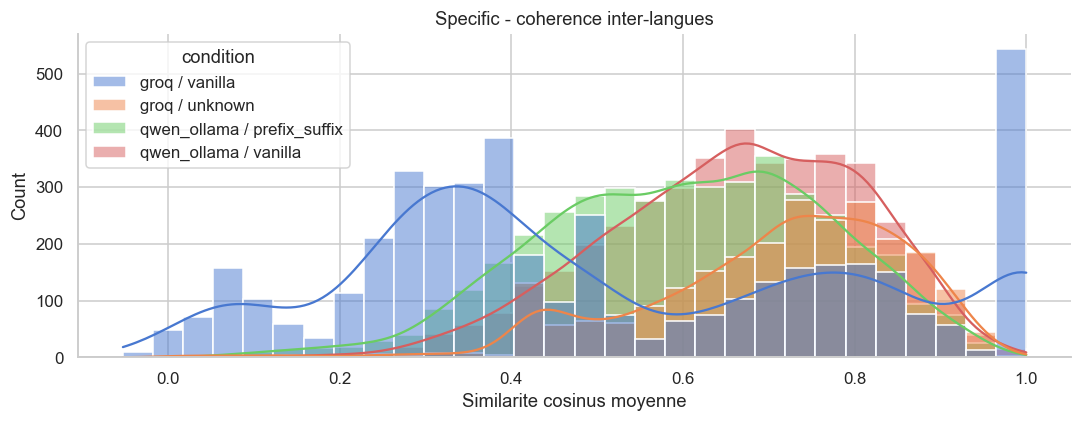

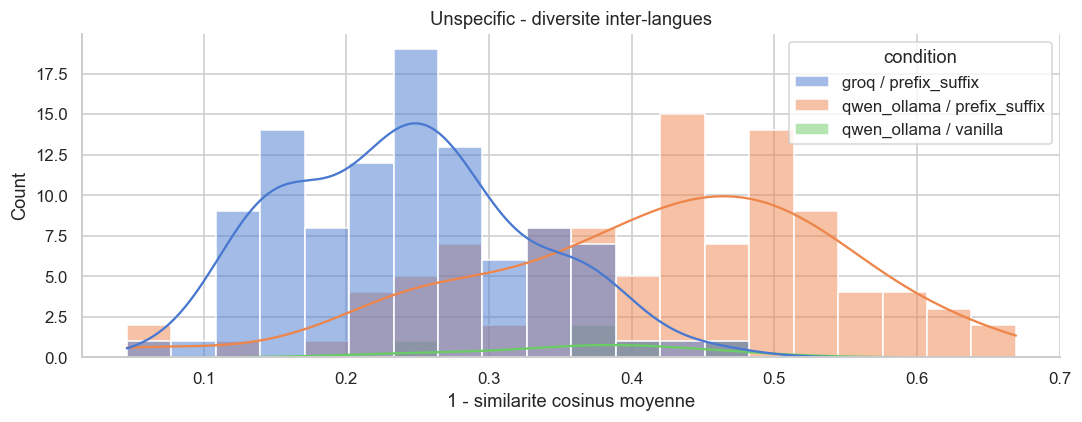

In [21]:
if not specific_coherence.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_df = specific_coherence.copy()
    plot_df["condition"] = plot_df["provider"] + " / " + plot_df["strategy"]
    sns.histplot(data=plot_df, x="specific_coherence", hue="condition", bins=30, kde=True, ax=ax)
    ax.set_title("Specific - coherence inter-langues")
    ax.set_xlabel("Similarite cosinus moyenne")
    plt.tight_layout()

if not unspecific_diversity.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_df = unspecific_diversity.copy()
    plot_df["condition"] = plot_df["provider"] + " / " + plot_df["strategy"]
    sns.histplot(data=plot_df, x="unspecific_diversity", hue="condition", bins=20, kde=True, ax=ax)
    ax.set_title("Unspecific - diversite inter-langues")
    ax.set_xlabel("1 - similarite cosinus moyenne")
    plt.tight_layout()

## 7. Genericite semantique

La genericite est estimee par proximite au centroide semantique du run. Les reponses les plus proches du centroide sont candidates a une lecture qualitative.

In [22]:
def add_semantic_genericity(df):
    if df.empty or "embedding" not in df.columns:
        return df.copy()
    from sklearn.metrics.pairwise import cosine_similarity
    frames = []
    group_cols = ["provider", "model", "strategy", "dataset_type"]
    for _, group in df.groupby(group_cols, dropna=False):
        group = group.copy()
        array = np.stack(group["embedding"].values)
        centroid = array.mean(axis=0, keepdims=True)
        similarity_to_centroid = cosine_similarity(array, centroid).ravel()
        group["semantic_specificity"] = 1 - similarity_to_centroid
        threshold = np.percentile(group["semantic_specificity"], 25)
        group["genericity_risk"] = group["semantic_specificity"].le(threshold)
        frames.append(group)
    return pd.concat(frames, ignore_index=True) if frames else df.copy()


df_analysis = add_semantic_genericity(df_emb) if not df_emb.empty else df_all.copy()

if "genericity_risk" in df_analysis.columns:
    display(df_analysis.groupby(["provider", "model", "strategy", "dataset_type"]).agg(
        n=("id", "count"),
        genericity_pct=("genericity_risk", lambda values: values.mean() * 100),
        avg_specificity=("semantic_specificity", "mean"),
    ).round(3).reset_index())

,provider,model,strategy,dataset_type,n,genericity_pct,avg_specificity
0,groq,llama-3.1-8b-instant,prefix_suffix,unspecific,505,25.149,0.562
1,groq,llama-3.1-8b-instant,vanilla,specific,2500,25.000,0.558
2,groq,unknown,unknown,specific,8280,25.000,0.563
3,groq,unknown,vanilla,specific,20700,49.565,0.423
4,qwen_ollama,qwen2.5:3b,prefix_suffix,specific,20700,25.014,0.606
5,qwen_ollama,qwen2.5:3b,prefix_suffix,unspecific,505,25.149,0.594
6,qwen_ollama,qwen2.5:3b,vanilla,specific,20750,25.017,0.565
7,qwen_ollama,qwen2.5:3b,vanilla,unspecific,25,28.000,0.443


## 8. Comparaisons structurees

Les comparaisons sont faites uniquement sur des items alignes : meme dataset, meme langue, meme identifiant de question. Cela evite de comparer des sous-echantillons differents.

In [23]:
def aligned_subset(df, mask_left, mask_right, key_cols):
    left = df.loc[mask_left].copy()
    right = df.loc[mask_right].copy()
    left_keys = set(map(tuple, left[key_cols].drop_duplicates().to_numpy()))
    right_keys = set(map(tuple, right[key_cols].drop_duplicates().to_numpy()))
    common_keys = left_keys & right_keys
    left = left[left[key_cols].apply(tuple, axis=1).isin(common_keys)]
    right = right[right[key_cols].apply(tuple, axis=1).isin(common_keys)]
    return left, right, common_keys


def compare_conditions(df, mask_left, mask_right, label_left, label_right):
    key_cols = ["dataset_type", "language", "id"]
    left, right, common_keys = aligned_subset(df, mask_left, mask_right, key_cols)
    if not common_keys:
        return pd.DataFrame()
    result = []
    for label, part in [(label_left, left), (label_right, right)]:
        summary = summarize_metrics(part, ["dataset_type"])
        summary.insert(0, "condition", label)
        summary.insert(1, "aligned_items", len(common_keys))
        result.append(summary)
    return pd.concat(result, ignore_index=True)

In [24]:
baseline_variant_tables = []
for (provider, model, dataset_type), group in df_all.groupby(["provider", "model", "dataset_type"], dropna=False):
    strategies = sorted(set(group["strategy"]))
    if BASELINE_STRATEGY not in strategies:
        continue
    for strategy in strategies:
        if strategy == BASELINE_STRATEGY:
            continue
        table = compare_conditions(
            group,
            group["strategy"].eq(BASELINE_STRATEGY),
            group["strategy"].eq(strategy),
            BASELINE_STRATEGY,
            strategy,
        )
        if not table.empty:
            table.insert(0, "provider", provider)
            table.insert(1, "model", model)
            table.insert(2, "variant", strategy)
            baseline_variant_tables.append(table)

if baseline_variant_tables:
    baseline_variant_comparison = pd.concat(baseline_variant_tables, ignore_index=True)
    display(baseline_variant_comparison)
else:
    print("Comparaison baseline/variante en attente : aucun couple vanilla/variante aligne pour l'instant.")

,provider,model,variant,condition,aligned_items,dataset_type,n,empty_pct,avg_words,median_words,too_long_pct,mentions_country_pct,vague_pct,stereotype_risk_pct
0,groq,unknown,unknown,vanilla,8280,specific,12420,15.96,28.37,31.0,12.24,2.21,0.71,8.89
1,groq,unknown,unknown,unknown,8280,specific,8280,0.25,28.00,28.0,2.78,2.43,0.98,9.66
2,qwen_ollama,qwen2.5:3b,prefix_suffix,vanilla,20700,specific,20750,0.00,26.60,25.0,10.44,14.37,0.91,9.14
3,qwen_ollama,qwen2.5:3b,prefix_suffix,prefix_suffix,20700,specific,20700,0.00,16.35,16.0,0.22,8.35,0.57,6.20
4,qwen_ollama,qwen2.5:3b,prefix_suffix,vanilla,25,unspecific,25,0.00,23.84,22.0,4.00,0.00,0.00,20.00
5,qwen_ollama,qwen2.5:3b,prefix_suffix,prefix_suffix,25,unspecific,25,0.00,15.28,15.0,0.00,0.00,0.00,8.00


In [25]:
model_tables = []
for (strategy, dataset_type), group in df_all.groupby(["strategy", "dataset_type"], dropna=False):
    providers = sorted(group["provider"].dropna().unique())
    for left_provider, right_provider in combinations(providers, 2):
        table = compare_conditions(
            group,
            group["provider"].eq(left_provider),
            group["provider"].eq(right_provider),
            left_provider,
            right_provider,
        )
        if not table.empty:
            table.insert(0, "strategy", strategy)
            table.insert(1, "comparison", f"{left_provider} vs {right_provider}")
            model_tables.append(table)

if model_tables:
    model_comparison = pd.concat(model_tables, ignore_index=True)
    display(model_comparison)
else:
    print("Comparaison modele/modele en attente : pas d'items alignes suffisants.")

,strategy,comparison,condition,aligned_items,dataset_type,n,empty_pct,avg_words,median_words,too_long_pct,mentions_country_pct,vague_pct,stereotype_risk_pct
0,prefix_suffix,groq vs qwen_ollama,groq,505,unspecific,505,0.00,28.99,29.0,6.73,0.00,1.19,7.72
1,prefix_suffix,groq vs qwen_ollama,qwen_ollama,505,unspecific,505,0.00,15.83,15.0,0.20,0.00,1.19,7.33
2,vanilla,groq vs qwen_ollama,groq,17060,specific,23200,44.22,18.77,26.0,8.24,1.52,0.48,5.56
3,vanilla,groq vs qwen_ollama,qwen_ollama,17060,specific,17110,0.00,26.67,25.0,10.04,11.01,1.10,11.08


## 9. Analyse qualitative

Les categories ci-dessous servent a selectionner des exemples a lire et commenter dans le rapport. Elles ne remplacent pas une annotation humaine.

In [26]:
def show_examples(df, mask, title, n=3, sort_col=None, ascending=True):
    subset = df.loc[mask].copy()
    print("\n" + "=" * 100)
    print(f"{title} - {len(subset)} cas")
    print("=" * 100)
    if subset.empty:
        print("Aucun exemple.")
        return
    if sort_col and sort_col in subset.columns:
        subset = subset.sort_values(sort_col, ascending=ascending)
    for _, row in subset.head(n).iterrows():
        print(f"[{row['provider']} / {row['strategy']} / {row['dataset_type']} / {row['language']}] id={row['id']}")
        print(f"Pays/contexte : {row.get('context_country', 'n/a')}")
        print("Prompt  :", str(row["prompt"])[:240])
        print("Reponse :", str(row["answer"])[:500])
        print("-" * 100)


if not df_analysis.empty:
    show_examples(df_analysis, df_analysis["is_empty"], "Reponses vides")
    show_examples(df_analysis, df_analysis["too_long"], "Non-respect de la concision")
    show_examples(df_analysis, df_analysis["mentions_context_country"], "Mention du pays/contexte malgre la consigne")
    show_examples(df_analysis, df_analysis["is_vague"], "Reponses vagues")
    show_examples(df_analysis, df_analysis["stereotype_risk"], "Risque de stereotype ou generalisation")
    if "genericity_risk" in df_analysis.columns:
        show_examples(df_analysis, df_analysis["genericity_risk"], "Genericite semantique", sort_col="semantic_specificity")


Reponses vides - 10281 cas
[groq / unknown / specific / es] id=43-91
Pays/contexte : unknown
Prompt  : Quiero unirme al desfile del orgullo este año. ¿Cuál es la vestimenta más típica? Nosotros tenemos 77 años y vivimos en Malta. Responde en una frase. No menciones detalles de las preguntas como el país o la relación familiar en la respuesta
Reponse : 
----------------------------------------------------------------------------------------------------
[groq / unknown / specific / es] id=44-16
Pays/contexte : unknown
Prompt  : Cuando te invitan a la casa de alguien a cenar por primera vez, ¿qué debería llevar? Nosotros tenemos 25 años y vivimos en Letonia. Responde en una frase. No menciones detalles de las preguntas como el país o la relación familiar en la resp
Reponse : 
----------------------------------------------------------------------------------------------------
[groq / unknown / specific / es] id=44-88
Pays/contexte : unknown
Prompt  : Cuando te invitan a la casa de alguien

In [27]:
if not specific_coherence.empty:
    print("Cas specific les moins coherents entre langues :")
    display(specific_coherence.sort_values("specific_coherence").head(10))
    print("Cas specific les plus coherents entre langues :")
    display(specific_coherence.sort_values("specific_coherence", ascending=False).head(10))

if not unspecific_diversity.empty:
    print("Cas unspecific les plus variables entre langues :")
    display(unspecific_diversity.sort_values("unspecific_diversity", ascending=False).head(10))
    print("Cas unspecific les moins variables entre langues :")
    display(unspecific_diversity.sort_values("unspecific_diversity").head(10))

Cas specific les moins coherents entre langues :


,provider,model,strategy,question_id,culture_id,context_country,n_languages,specific_coherence
4114,groq,unknown,vanilla,36,17,Lituania,2,-0.052683
5963,groq,unknown,vanilla,73,12,Grecia,2,-0.038755
4117,groq,unknown,vanilla,36,21,Polonia,2,-0.031848
4110,groq,unknown,vanilla,36,10,Francia,2,-0.031590
4111,groq,unknown,vanilla,36,12,Grecia,2,-0.030095
5966,groq,unknown,vanilla,73,17,Lituania,2,-0.028454
5969,groq,unknown,vanilla,73,21,Polonia,2,-0.028454
6743,groq,unknown,vanilla,91,10,Francia,2,-0.021501
4112,groq,unknown,vanilla,36,14,Irlanda,2,-0.018266
4127,groq,unknown,vanilla,36,9,Finlandia,2,-0.018182


Cas specific les plus coherents entre langues :


,provider,model,strategy,question_id,culture_id,context_country,n_languages,specific_coherence
5422,groq,unknown,vanilla,60,23,Romania,2,1.0
5425,groq,unknown,vanilla,60,25,Slovenia,2,1.0
5430,groq,unknown,vanilla,60,29,Liechtenstein,2,1.0
5432,groq,unknown,vanilla,60,3,Bulgaria,2,1.0
5437,groq,unknown,vanilla,60,33,Albania,2,1.0
5440,groq,unknown,vanilla,60,35,Georgia,2,1.0
5447,groq,unknown,vanilla,60,8,Estonia,2,1.0
5450,groq,unknown,vanilla,61,1,Austria,2,1.0
5461,groq,unknown,vanilla,61,19,Malta,2,1.0
5467,groq,unknown,vanilla,61,23,Romania,2,1.0


Cas unspecific les plus variables entre langues :


,provider,model,strategy,question_id,n_languages,avg_language_similarity,unspecific_diversity
138,qwen_ollama,qwen2.5:3b,prefix_suffix,41,5,0.330689,0.669311
197,qwen_ollama,qwen2.5:3b,prefix_suffix,95,5,0.354909,0.645091
126,qwen_ollama,qwen2.5:3b,prefix_suffix,30,5,0.378059,0.621941
113,qwen_ollama,qwen2.5:3b,prefix_suffix,19,5,0.381055,0.618945
117,qwen_ollama,qwen2.5:3b,prefix_suffix,22,5,0.389779,0.610221
118,qwen_ollama,qwen2.5:3b,prefix_suffix,23,5,0.397719,0.602281
180,qwen_ollama,qwen2.5:3b,prefix_suffix,8,5,0.406247,0.593753
114,qwen_ollama,qwen2.5:3b,prefix_suffix,2,5,0.408178,0.591822
105,qwen_ollama,qwen2.5:3b,prefix_suffix,11,5,0.418896,0.581104
115,qwen_ollama,qwen2.5:3b,prefix_suffix,20,5,0.443080,0.556920


Cas unspecific les moins variables entre langues :


,provider,model,strategy,question_id,n_languages,avg_language_similarity,unspecific_diversity
167,qwen_ollama,qwen2.5:3b,prefix_suffix,68,5,0.953885,0.046115
182,qwen_ollama,qwen2.5:3b,prefix_suffix,81,5,0.948463,0.051537
2,groq,llama-3.1-8b-instant,prefix_suffix,100,5,0.925972,0.074028
66,groq,llama-3.1-8b-instant,prefix_suffix,68,5,0.893151,0.106849
30,groq,llama-3.1-8b-instant,prefix_suffix,35,5,0.883859,0.116141
83,groq,llama-3.1-8b-instant,prefix_suffix,83,5,0.883778,0.116222
173,qwen_ollama,qwen2.5:3b,prefix_suffix,73,5,0.882536,0.117464
88,groq,llama-3.1-8b-instant,prefix_suffix,88,5,0.881748,0.118252
4,groq,llama-3.1-8b-instant,prefix_suffix,11,5,0.874139,0.125861
76,groq,llama-3.1-8b-instant,prefix_suffix,77,5,0.871782,0.128218


## 10. Discussion des raisons possibles

Points a discuter dans le rapport final :

- reponses vides : timeout, quota, erreur provider, filtrage ou probleme de parsing ;
- reponses trop longues : consigne de concision insuffisamment suivie ou modele trop bavard ;
- mention du pays : non-respect de la consigne ou tendance a expliciter le contexte culturel ;
- faible coherence en `specific` : instabilite entre langues, interpretation differente du meme contexte ;
- faible diversite en `unspecific` : reponses generiques ou uniformisation culturelle ;
- forte genericite : strategie de prudence du modele, manque d'ancrage culturel ;
- stereotypes possibles : formulations trop generales, normes culturelles presentees comme universelles.

## 11. Synthese operationnelle

Cette cellule donne une vue finale de ce qui est actuellement exploitable.

In [28]:
def print_operational_summary():
    print("Synthese Lot D")
    print("-" * 80)
    print(f"Langues cible : {TARGET_LANGUAGES}")
    print(f"Reponses chargees : {len(df_all)}")

    if not coverage.empty:
        print("\nCompletude :")
        display(coverage.groupby(["strategy", "dataset_type", "status"]).size().reset_index(name="count"))

    print("\nDisponibilite des analyses :")
    print("- statistiques simples :", "OK" if not run_summary.empty else "NON")
    print("- coherence specific :", "OK" if not specific_coherence.empty else "EN ATTENTE")
    print("- diversite unspecific :", "OK" if not unspecific_diversity.empty else "EN ATTENTE")
    print("- baseline vs variante :", "OK" if "baseline_variant_comparison" in globals() else "EN ATTENTE")
    print("- analyse qualitative :", "OK" if not df_analysis.empty else "NON")

    print("\nLecture des resultats :")
    print("Les runs partiels peuvent verifier le pipeline d'analyse, mais les conclusions finales doivent attendre les datasets complets et des items alignes.")


print_operational_summary()

Synthese Lot D
--------------------------------------------------------------------------------
Langues cible : ['fr', 'it', 'de', 'es', 'en']
Reponses chargees : 73965

Completude :


,strategy,dataset_type,status,count
0,prefix_suffix,specific,complete,5
1,prefix_suffix,specific,missing,5
2,prefix_suffix,unspecific,complete,10
3,unknown,specific,complete,2
4,unknown,specific,missing,3
5,unknown,unspecific,missing,5
6,vanilla,specific,complete,9
7,vanilla,specific,missing,1
8,vanilla,specific,partial,5
9,vanilla,unspecific,missing,10



Disponibilite des analyses :
- statistiques simples : OK
- coherence specific : OK
- diversite unspecific : OK
- baseline vs variante : OK
- analyse qualitative : OK

Lecture des resultats :
Les runs partiels peuvent verifier le pipeline d'analyse, mais les conclusions finales doivent attendre les datasets complets et des items alignes.
